# Markowitz Mean-Variance Optimization

This is a problem where we want to find the optimal portfolio allocation that minimizes risk for a given level of expected return, or equivalently, maximizes expected return for a given level of risk.

We know that,
$$R_p = \sum_{i=1}^{n} w_i R_i = w^T R$$

Expected return of stocks:
$$E[R_p] =  \sum_{i=1}^{n} w_i E[R_i]$$

Variance of the portfolio:
$$\sigma_p^2 = Var(R_p) = Var(w^T R) = w^T \Sigma w = \sum_{i=1}^{n} \sum_{j=1}^{n} w_i w_j Cov(R_i, R_j)$$


## Minimize Variance problem

Objective function: $$\min_{w} w^T \Sigma w$$
Constraints: 
1. $\sum_{i=1}^{n} w_i = 1$
2. $w_i \geq 0$ for all $i = 1, \dots, n$
3. $E[R_p] = \sum_{i=1}^{n} w_i E[R_i] \geq R_{target}$

Since $\Sigma$ is positive semi-definite, this is a convex optimization problem. We can solve it using quadratic programming or other convex optimization techniques.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import scipy.optimize as sco
import cvxpy as cp
import yfinance as yf

In [34]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']
data = yf.download(tickers, start='2020-01-01', end='2020-12-31')['Close']
returns = data.pct_change().dropna()
mean_returns = returns.mean() * 252 # Annualize the mean returns
cov_matrix = returns.cov() * 252 # Annualize the covariance matrix

mean_returns.values, cov_matrix.values

[*********************100%***********************]  5 of 5 completed


(array([0.69780596, 0.62548636, 0.31330966, 0.36646719, 0.43109322]),
 array([[0.21884499, 0.12577645, 0.13570814, 0.16528551, 0.1729193 ],
        [0.12577645, 0.1487751 , 0.10048351, 0.12110256, 0.12548348],
        [0.13570814, 0.10048351, 0.1486219 , 0.14163379, 0.14565204],
        [0.16528551, 0.12110256, 0.14163379, 0.21191006, 0.15467152],
        [0.1729193 , 0.12548348, 0.14565204, 0.15467152, 0.19383554]]))

Now, optimizing variance with expected return of 9% or more.

In [ ]:
target_return = 0.09
w = cp.Variable(len(tickers))
objective = cp.Minimize(cp.quad_form(w, cov_matrix.values))  # Minimize variance
constraints = [
    cp.sum(w) == 1, 
    w >= 0, 
    mean_returns.values @ w >= target_return 
]

prob = cp.Problem(objective, constraints)
prob.solve()
print("Optimal weights:", w.value)

Optimal weights: [-5.73039328e-23  4.99205639e-01  5.00794361e-01 -1.21870408e-23
  1.73111169e-23]


# Tobin's separation theorem

Here, we will find the optimal risky portfolio (tangency portfolio) by maximizing the Sharpe ratio, and then combine it with the risk-free asset to achieve the desired expected return.

Objective: $\max_{w} \frac{w^T \mu - r_f}{\sqrt{w^T \Sigma w}}$

Subject to: $\sum_{i=1}^{n} w_i = 1$ and $w_i \geq 0$ for all $i$.

But, this is not a convex problem due to the ratio in the objective function. We can reformulate it as a convex problem by maximizing the numerator while keeping the denominator fixed, or by using a different approach such as maximizing the difference between expected return and risk-free rate subject to a constraint on variance.



```python
risk_free_rate = 0.04
w = cp.Variable(len(tickers))
objective = cp.Minimize(- 
    (mean_returns.values @ w - risk_free_rate) 
    / cp.sqrt(cp.quad_form(w, cov_matrix.values))
)
constraints = [
    cp.sum(w) == 1, 
    w >= 0
]

prob = cp.Problem(objective, constraints)
prob.solve()
print("Optimal weights:", w.value)
```

```error 
---------------------------------------------------------------------------
DCPError                                  Traceback (most recent call last)
Cell In[19], line 13
      7 constraints = [
      8     cp.sum(w) == 1, 
      9     w >= 0
     10 ]
     12 prob = cp.Problem(objective, constraints)
---> 13 prob.solve()
     14 print("Optimal weights:", w.value)

File c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\cvxpy\problems\problem.py:649, in Problem.solve(self, *args, **kwargs)
    646         raise ValueError(
    647             "Cannot specify both 'solver' and 'solver_path'. Please choose one.")
    648     return self._solve_solver_path(solve_func,solver_path, args, kwargs)
--> 649 return solve_func(self, *args, **kwargs)

File c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\cvxpy\problems\problem.py:1215, in Problem._solve(self, solver, warm_start, verbose, bibtex, gp, qcp, requires_grad, enforce_dpp, ignore_dpp, canon_backend, **kwargs)
   1212         self.unpack(chain.retrieve(soln))
   1213         return self.value
-> 1215 data, solving_chain, inverse_data = self.get_problem_data(
   1216     solver, gp, enforce_dpp, ignore_dpp, verbose, canon_backend, kwargs
   1217 )
   1219 if verbose:
   1220     print(_NUM_SOLVER_STR)

File c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\cvxpy\problems\problem.py:795, in Problem.get_problem_data(self, solver, gp, enforce_dpp, ignore_dpp, verbose, canon_backend, solver_opts)
    793 if key != self._cache.key:
    794     self._cache.invalidate()
--> 795     solving_chain = self._construct_chain(
    796         solver=solver, gp=gp,
    797         enforce_dpp=enforce_dpp,
    798         ignore_dpp=ignore_dpp,
    799         canon_backend=canon_backend,
    800         solver_opts=solver_opts)
    801     self._cache.key = key
    802     self._cache.solving_chain = solving_chain

File c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\cvxpy\problems\problem.py:1033, in Problem._construct_chain(self, solver, gp, enforce_dpp, ignore_dpp, canon_backend, solver_opts)
   1031 candidate_solvers = self._find_candidate_solvers(solver=solver, gp=gp)
   1032 self._sort_candidate_solvers(candidate_solvers)
-> 1033 return construct_solving_chain(self, candidate_solvers, gp=gp,
   1034                                enforce_dpp=enforce_dpp,
   1035                                ignore_dpp=ignore_dpp,
   1036                                canon_backend=canon_backend,
   1037                                solver_opts=solver_opts,
   1038                                specified_solver=solver)

File c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:247, in construct_solving_chain(problem, candidates, gp, enforce_dpp, ignore_dpp, canon_backend, solver_opts, specified_solver)
    245 if len(problem.variables()) == 0:
    246     return SolvingChain(reductions=[ConstantSolver()])
--> 247 reductions = _reductions_for_problem_class(problem, candidates, gp, ignore_dpp,
    248                                            solver_opts)
    250 # Process DPP status of the problem.
    251 dpp_context = 'dcp' if not gp else 'dgp'

File c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:162, in _reductions_for_problem_class(problem, candidates, gp, ignore_dpp, solver_opts)
    159     elif problem.is_dqcp():
    160         append += ("\nHowever, the problem does follow DQCP rules. "
    161                    "Consider calling solve() with `qcp=True`.")
--> 162     raise DCPError(
    163         "Problem does not follow DCP rules. Specifically:\n" + append)
    164 elif gp and not problem.is_dgp():
    165     append = build_non_disciplined_error_msg(problem, 'DGP')

DCPError: Problem does not follow DCP rules. Specifically:
The objective is not DCP. Its following subexpressions are not:
PowerApprox(QuadForm(var241, [[0.22 0.13 ... 0.17 0.17]
 [0.13 0.15 ... 0.12 0.13]
 ...
 [0.17 0.12 ... 0.21 0.15]
 [0.17 0.13 ... 0.15 0.19]]), 0.5)
```

# Charnes-Cooper transformation

We can introduce a new variable $t$ and rewrite the problem as:
$$\max_{w, t} t (w^T \mu - r_f)$$
Subject to:
1. $\sum_{i=1}^{n} w_i = 1$
2. $w_i \geq 0$ for all $i$
3. $t \sqrt{w^T \Sigma w} = 1$
This transformation allows us to convert the original non-convex problem into a convex optimization problem that can be solved using standard techniques.

-- OR --

We can introduce a new variable $t$ and rewrite the problem as:
$$\min x^T\Sigma x$$
where
1. $x = c * w$
2. $x^T \mu - R_f \sum x = 1$

Since return is locked, we can minimize variance of x, instead of w, which is identical to maximizing Sharpe ratio. This is a convex optimization problem that can be solved using standard techniques.

In [23]:
risk_free_rate = 0.04
x = cp.Variable(len(tickers))

# Maximize sharpe ratio by charnes-cooper transformation
objective = cp.Minimize(cp.quad_form(x, cov_matrix.values)) 

constraints = [
    x @ mean_returns.values - risk_free_rate * cp.sum(x) == 1,
    x >= 0 ## Long only
]

prob = cp.Problem(objective, constraints)
prob.solve()
print("Optimal weights:", x.value)

optimal_weights = x.value / np.sum(x.value) 
print("Optimal weights:", optimal_weights)

Optimal weights: [5.69821127e-01 1.06777598e+00 4.93714925e-23 1.16678302e-22
 1.20693189e-22]
Optimal weights: [3.47961734e-01 6.52038266e-01 3.01487420e-23 7.12496999e-23
 7.37013939e-23]


# Effective frontier

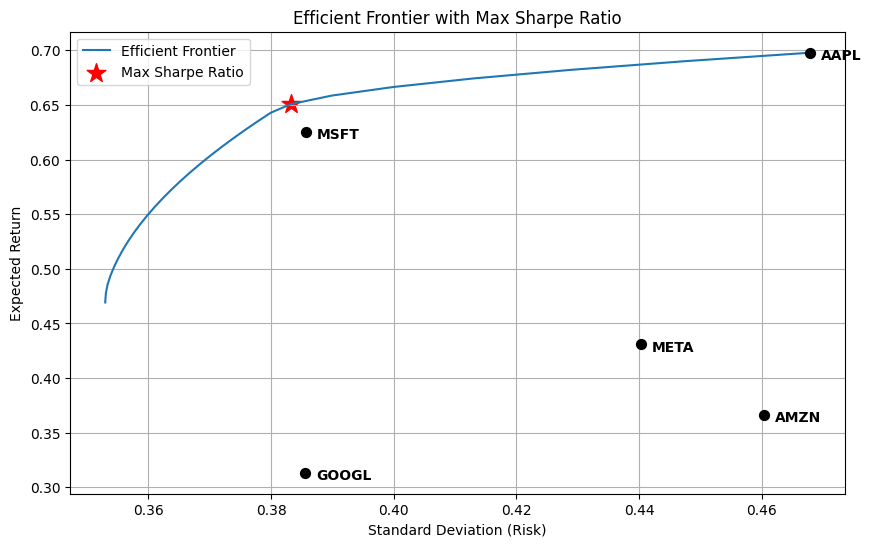

In [40]:
def get_max_sharpe_portfolio_weights(mean_returns, cov_matrix, risk_free_rate=0.04):
    x = cp.Variable(len(tickers))

    # We are trying to maximize the sharpe ratio
    objective = cp.Minimize(cp.quad_form(x, cov_matrix.values)) 

    constraints = [
        x @ mean_returns.values - risk_free_rate * cp.sum(x) == 1,
        x >= 0 ## Long only
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()
    optimal_weights = x.value / np.sum(x.value)
    return optimal_weights

def get_information(mean_returns, cov_matrix, risk_free_rate=0.04):
    optimal_weights = get_max_sharpe_portfolio_weights(mean_returns, cov_matrix, risk_free_rate)
    portfolio_return = optimal_weights @ mean_returns.values
    portfolio_variance = optimal_weights.T @ cov_matrix.values @ optimal_weights
    sharpe_ratio = (portfolio_return - risk_free_rate) / np.sqrt(portfolio_variance)
    return optimal_weights, portfolio_return, portfolio_variance, sharpe_ratio

def get_effective_frontier(mean_returns, cov_matrix, target_returns, risk_free_rate=0.04):
    w = cp.Variable(len(tickers))
    target = cp.Parameter()
    objective = cp.Minimize(cp.quad_form(w, cov_matrix.values))  # Minimize variance
    constraints = [
        cp.sum(w) == 1, 
        w >= 0, 
        mean_returns.values @ w >= target 
    ]
    frontier_return = []
    frontier_variance = []

    # Find for various targets
    for target_return in target_returns:
        target.value = target_return
        prob = cp.Problem(objective, constraints)
        prob.solve()
        if prob.status != cp.OPTIMAL: continue
        frontier_return.append(w.value @ mean_returns.values)
        frontier_variance.append(w.value.T @ cov_matrix.values @ w.value)
    return np.array(frontier_return), np.array(frontier_variance)


ms_weights, ms_return, ms_variance, ms_sharpe = get_information(mean_returns, cov_matrix, risk_free_rate)
min_ret, max_ret = np.min(mean_returns.values), np.max(mean_returns.values)
target_returns = np.linspace(min_ret, max_ret, 50)
frontier_return, frontier_variance = get_effective_frontier(mean_returns, cov_matrix, target_returns, risk_free_rate)

plt.figure(figsize=(10, 6))
plt.plot(frontier_variance**0.5, frontier_return, label='Efficient Frontier')
plt.scatter(ms_variance**0.5, ms_return, color='red', marker='*', s=200, label='Max Sharpe Ratio')
plt.title('Efficient Frontier with Max Sharpe Ratio')
plt.xlabel('Standard Deviation (Risk)')
plt.ylabel('Expected Return')

plt.legend()
plt.grid()

# Plot individual stocks for context
for i, ticker in enumerate(tickers):
    stdev = np.sqrt(cov_matrix.iloc[i, i])
    ret = mean_returns.iloc[i]
    plt.scatter(stdev, ret, color='black', s=50, zorder=4)
    plt.annotate(ticker, (stdev, ret), xytext=(8, -5), textcoords='offset points', fontweight='bold')


plt.show()

Optimizing Portfolios...


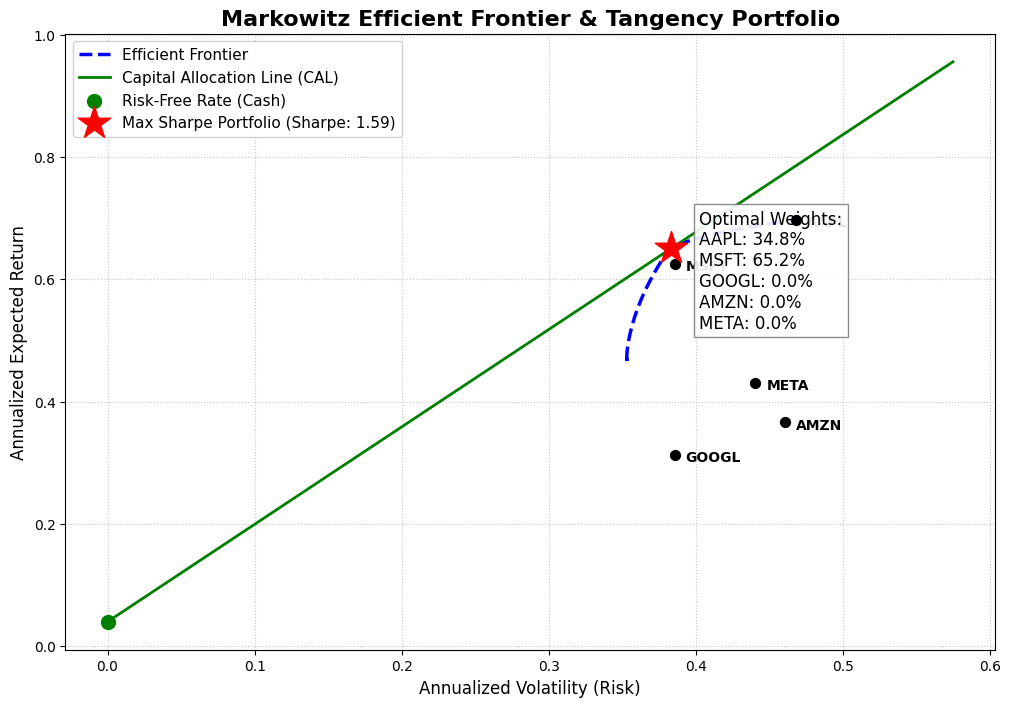

In [32]:
import yfinance as yf
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

def get_max_sharpe_portfolio(mean_returns, cov_matrix, risk_free_rate=0.04):
    """Solves for the Tangency Portfolio using the Charnes-Cooper Transformation."""
    n = len(mean_returns)
    x = cp.Variable(n)
    
    # Objective: Minimize Variance of the unnormalized variable
    objective = cp.Minimize(cp.quad_form(x, cp.psd_wrap(cov_matrix)))
    
    # Constraints: Lock excess return to 1, Long-only
    constraints = [
        x @ mean_returns - risk_free_rate * cp.sum(x) == 1,
        x >= 0
    ]
    
    prob = cp.Problem(objective, constraints)
    prob.solve()
    
    # Normalize back to weights that sum to 1
    optimal_weights = x.value / np.sum(x.value)
    
    # Clean up floating point noise
    optimal_weights = np.round(optimal_weights, 4)
    optimal_weights[optimal_weights < 0] = 0.0
    optimal_weights /= np.sum(optimal_weights) # Re-normalize
    
    # Calculate final Return and Risk
    opt_ret = np.dot(optimal_weights, mean_returns)
    opt_std = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights)))
    
    return optimal_weights, opt_ret, opt_std

def get_efficient_frontier(mean_returns, cov_matrix, targets):
    """Calculates the minimum variance for a list of target returns."""
    n = len(mean_returns)
    w = cp.Variable(n)
    target = cp.Parameter()
    
    objective = cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov_matrix)))
    constraints = [cp.sum(w) == 1, w >= 0, w @ mean_returns >= target]
    prob = cp.Problem(objective, constraints)
    
    frontier_std, frontier_ret = [], []
    
    for t in targets:
        target.value = t
        try:
            prob.solve()
            if prob.status == 'optimal':
                std = np.sqrt(np.dot(w.value.T, np.dot(cov_matrix, w.value)))
                frontier_std.append(std)
                frontier_ret.append(np.dot(w.value, mean_returns))
        except:
            pass # Skip if no feasible solution found
            
    return frontier_std, frontier_ret

# ==========================================
# EXECUTION & PLOTTING
# ==========================================

# 1. Fetch Data
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']
print("Downloading Data...")
data = yf.download(tickers, start='2020-01-01', end='2020-12-31', progress=False)['Close']
returns = data.pct_change().dropna()

mean_returns = returns.mean().values * 252
cov_matrix = returns.cov().values * 252
risk_free_rate = 0.04

# 2. Run the Quant Models
print("Optimizing Portfolios...")
ms_weights, ms_ret, ms_std = get_max_sharpe_portfolio(mean_returns, cov_matrix, risk_free_rate)

# Generate 50 points along the frontier
min_ret, max_ret = np.min(mean_returns), np.max(mean_returns)
targets = np.linspace(min_ret, max_ret, 50)
f_std, f_ret = get_efficient_frontier(mean_returns, cov_matrix, targets)

# 3. Build the Plot
plt.figure(figsize=(12, 8))

# Plot the Efficient Frontier curve
plt.plot(f_std, f_ret, 'b--', linewidth=2.5, label='Efficient Frontier')

# Plot individual stocks for context
for i, ticker in enumerate(tickers):
    stdev = np.sqrt(cov_matrix[i, i])
    ret = mean_returns[i]
    plt.scatter(stdev, ret, color='black', s=50, zorder=4)
    plt.annotate(ticker, (stdev, ret), xytext=(8, -5), textcoords='offset points', fontweight='bold')

# Plot the Capital Allocation Line (CAL) - The Cash/Stock Mix
cal_x = [0, ms_std, ms_std * 1.5]
cal_y = [risk_free_rate, ms_ret, risk_free_rate + ((ms_ret - risk_free_rate) / ms_std) * (ms_std * 1.5)]
plt.plot(cal_x, cal_y, 'g-', linewidth=2, label='Capital Allocation Line (CAL)')
plt.scatter(0, risk_free_rate, color='green', s=100, zorder=5, label='Risk-Free Rate (Cash)')

# Plot the Max Sharpe Tangency point (The Red Star)
plt.scatter(ms_std, ms_ret, color='red', marker='*', s=600, zorder=5, 
            label=f'Max Sharpe Portfolio (Sharpe: {(ms_ret-risk_free_rate)/ms_std:.2f})')

# Formatting the Chart
plt.title('Markowitz Efficient Frontier & Tangency Portfolio', fontsize=16, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Expected Return', fontsize=12)
plt.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.7)

# Add a text box with the winning weights
weight_text = "Optimal Weights:\n" + "\n".join([f"{t}: {w*100:.1f}%" for t, w in zip(tickers, ms_weights)])
plt.text(ms_std*1.05, ms_ret*0.8, weight_text, fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.show()